In [1]:
models = ['llama-3.1-8b-instant',"llama-3.3-70b-versatile","openai/gpt-oss-120b","openai/gpt-oss-20b","whisper-large-v3","whisper-large-v3-turbo","groq/compound",""]

In [2]:
from langchain_groq import ChatGroq
from langchain_experimental.utilities import PythonREPL
from langchain_experimental.tools import PythonREPLTool
from langchain_community.tools import ShellTool
from typing import Optional
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage, ToolMessage
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import PydanticOutputParser, JsonOutputParser, StrOutputParser
from langsmith import traceable
from tavily import TavilyClient
from dotenv import load_dotenv
from pydantic import BaseModel, Field
import platform
from langgraph.graph import StateGraph, START, END
import os
from IPython.display import display, Image
load_dotenv()  # Load environment variables from .env file


/var/folders/59/rqk_86615px1gwrqjvq0c1qm0000gn/T/ipykernel_48091/3918923200.py:2: DeprecationWarning: `langchain-experimental` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-experimental/issues/87 for details.
  from langchain_experimental.utilities import PythonREPL
/var/folders/59/rqk_86615px1gwrqjvq0c1qm0000gn/T/ipykernel_48091/3918923200.py:4: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import ShellTool


True

In [75]:
model_names = ["qwen/qwen3.6-27b","llama-3.3-70b-versatile","openai/gpt-oss-120b"]
llm = ChatGroq(
    model=model_names[1],
    temperature=0.7,)

import dspy

groq_lm = dspy.LM(
    f'groq/{model_names[1]}', # Format: groq/<model-name>
)
groq_lm1 = dspy.LM(
    'groq/openai/gpt-oss-120b', # Format: groq/<model-name>
    api_key = os.environ.get('GROQ_API_KEY'),
)
dspy.configure(lm=groq_lm)
groq_lm.inspect_history(n=5)
groq_lm1.inspect_history(n=5)


In [76]:
class state(BaseModel):
    query: str = Field(description="The query to be processed by the model.")
    todo_list : Optional[dict]  = Field(default={}, description="write the to do list to be done for this task")
    code : Optional[dict] = Field(default = {}, description="The code generated by the model in response to the query.")
    command : Optional[dict] = Field(default = {}, description="The command generated by the model in response to read or write the code.")
    error : Optional[str] = Field(default=None,description="The error casused")
    test_cases : Optional[str] = Field(default = None, description="The test cases generated by the model for the code.")
    current_step : Optional[int] = Field(default=None, description="Current step for executing codes")
    is_implemented : Optional[bool] = Field(default=None, description="entire is implemented or not")


In [77]:
@traceable
def create_todotask(state_obj : state):
    print("state at create todotask", state_obj)

    template = """You are an expert software architect and project manager. Your task is to break down a given project into a highly modular folder structure and provide a step-by-step to-do list for implementation.
    this step by step will be different different modules or py files at different directries. you need to orchastrate them for this code generation.
    do whatever is being asked do not add anything extra
    You must return the output EXCLUSIVELY as a valid JSON dictionary. Do not include any conversational text, markdown formatting (like ```json), or explanations outside of the JSON object.
    just keep it simple and dont add anything for deployment if not asked and make it simplified as possible
    you can start the folder from this{{agent/}}
    The JSON dictionary must strictly follow this schema:
    {{
    "project_name": "Name of the project",
    "architecture_summary": "A 1-2 sentence summary of the modular approach.",
    "folder_structure": {{
        // Represent the directory tree here using nested dictionaries. 
        // The keys are folder/file names. The values are either nested dictionaries (for subfolders) or string descriptions (for files/folder purposes).
    }},
    "todo_list": [
        {{
        "step_number": 1,
        "task_name": "Name of the task",
        "description": "What needs to be done in detail withput mentioning where to write or any path",
        "target_file_or_folder": "Where this code belongs in the structure",
        "dependencies": ["List of step numbers that must be completed first"],
        is_implemented: None
        }}
    ]
    }}

    PROJECT TASK:
    {input_query}"""
    output_parser = JsonOutputParser()
    prompt = PromptTemplate(
        template=template,
        input_variables=['input_query'],
    )
    chain = prompt | llm | output_parser
    result = chain.invoke({"input_query" : state_obj.query})
    state_obj.todo_list = result
    return state_obj



In [78]:
def redirect(state_obj : state):

    print("state at redirect", state_obj)

    
    todo_list = state_obj.todo_list['todo_list']
    

    for ind,todo in enumerate(todo_list):
        if todo['is_implemented'] is None:
            state_obj.current_step = ind
            
            return state_obj
    state_obj.is_implemented = True
    return state_obj

In [79]:
class write_code(BaseModel):
    code: Optional[str]  = Field(default=None , description="generated Code")
class write_command(BaseModel):
    command: Optional[str]  = Field(default=None , description="generated Code")

In [80]:

class transform_code(dspy.Signature):
    """convert into moduler code"""
    input_string = dspy.InputField()
    code = dspy.OutputField(desc="a proper runnable code with testcases included")


In [81]:
@traceable
def implement_code(state_obj:state):
    print("state at create implement code", state_obj)

    current_step = state_obj.current_step
    print(f"============= We are at step {current_step} ========================\n\n")
    print(state_obj.todo_list['todo_list'][current_step])
    
    generate_code = dspy.ProgramOfThought(transform_code, max_iters=10)
    response = generate_code(input_string=state_obj.todo_list['todo_list'][current_step]["description"])
    state_obj.code["step_number_" + str(state_obj.todo_list['todo_list'][current_step]["step_number"])] = response.code
    return state_obj


In [82]:
@traceable
def implement_command(state_obj:state):

    print("state at create implement command", state_obj)

    current_step = state_obj.current_step
    command_executor = [ShellTool()]
    llm_with_command_executor = llm.bind_tools(command_executor)
    current_task = state_obj.todo_list['todo_list'][current_step]

    generated_code = state_obj.code['step_number_' + str(current_task["step_number"]) ]
    message = [
        SystemMessage(content= f"You are an expart of shell command and you are using {platform.system()}"
                      "you are suppose to the task given"
                      "you can use the tools to check if everything is fine to use or not"
                      f"these are the tools you can use {command_executor}"
                      "do not assume anything",
                      ),
        HumanMessage(content=f"You are suppose to write into this file {str(current_task['target_file_or_folder'])} the following code:\n\n"
                             f"{generated_code}\n\n"
                             "The tool is to run shell command. You have to create the shell command to write the above code into the file. "
                             "To prevent quote-escaping issues, use the 'cat' heredoc method. "
                             "do the necessary for the errors if provided"
                             )
    ]
    tool_dict = {t.name : t for t in command_executor}
    tool_args = None
    for i in range(1,10):
        response = llm_with_command_executor.invoke(message)
        tool_calls = response.tool_calls
        
        if not tool_calls:
            state_obj.command["step_number_" + str(state_obj.todo_list['todo_list'][current_step]["step_number"])] = tool_args
            state_obj.todo_list['todo_list'][current_step]['is_implemented'] = True
            return response
        tool_name = tool_calls[0]['name']
        tool_args = tool_calls[0]['args']
        tool_id = tool_calls[0]['id']

        tool_response = tool_dict[tool_name].invoke(tool_args)
        message.append(response)
        tool_message = ToolMessage(content=str(tool_response), tool_call_id = tool_id )
        message.append(tool_message)

        print(f"=================iteration {i}===================\n\n")
        print("tool_message",tool_message)
        print("tool_calls",tool_calls)
        print("response",response.content)





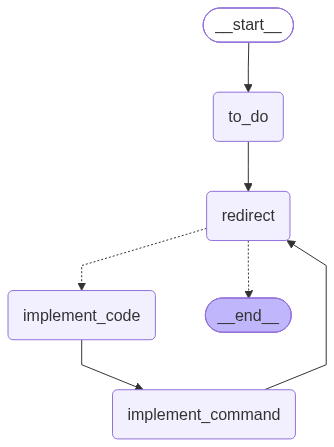

In [83]:
workflow = StateGraph(state)
workflow.add_node("to_do",create_todotask)
workflow.add_node("redirect",redirect)
workflow.add_node("implement_code",implement_code)
workflow.add_node("implement_command",implement_command)

workflow.add_edge(START, "to_do")
workflow.add_edge("to_do","redirect")


def route_to_next_task(state_obj: state):
    if not state_obj.is_implemented:
        return "implement_code"
    return END

workflow.add_conditional_edges(
    "redirect",
    route_to_next_task,
    {
        "implement_code":"implement_code",
        END:END
    }
    
)
workflow.add_edge("implement_code","implement_command")
workflow.add_edge("implement_command","redirect")

agent = workflow.compile()

display(Image(agent.get_graph().draw_mermaid_png()))


In [85]:
agent.invoke({"query":"write a code to check if a number is prime or not"})

state at create todotask query='write a code to check if a number is prime or not' todo_list={} code={} command={} error=None test_cases=None current_step=None is_implemented=None
state at redirect query='write a code to check if a number is prime or not' todo_list={'project_name': 'Prime Number Checker', 'architecture_summary': 'The project follows a modular approach with separate modules for utility functions and the main application logic.', 'folder_structure': {'agent': {'utils': {'math_utils.py': 'Utility functions for mathematical operations', '__init__.py': 'Package initializer'}, 'app': {'prime_checker.py': 'Main application logic for prime number checking', '__init__.py': 'Package initializer'}, '__init__.py': 'Package initializer'}}, 'todo_list': [{'step_number': 1, 'task_name': 'Create a function to check if a number is prime', 'description': 'Write a function that takes an integer as input and returns True if it is prime, False otherwise. The function should handle edge cas

/Users/jyostnabanik/AI Agents/.agent/lib/python3.14/site-packages/langchain_community/tools/shell/tool.py:33: UserWarning: The shell tool has no safeguards by default. Use at your own risk.
  warnings.warn(


Executing command:
 ['cat > agent/utils/math_utils.py << EOF\nimport math\n\ndef is_prime(n):\n    """\n    Checks if a number is prime.\n    \n    Parameters:\n    n (int): The number to check.\n    \n    Returns:\n    bool: True if the number is prime, False otherwise.\n    """\n    \n    # Check if input is an integer\n    if not isinstance(n, int):\n        raise TypeError("Input must be an integer.")\n    \n    # Handle edge cases\n    if n < 2:\n        return False\n    \n    # Check for divisibility up to the square root of n\n    for i in range(2, int(math.sqrt(n)) + 1):\n        if n % i == 0:\n            return False\n    \n    return True\n\n# Test the function\nprint(is_prime(25))  # Should return False\nprint(is_prime(23))  # Should return True\nprint(is_prime(37))  # Should return True\nprint(is_prime(48))  # Should return False\n\ndef test_is_prime():\n    # Test cases\n    test_cases = [\n        (25, False),\n        (23, True),\n        (37, True),\n        (48, Fal

/Users/jyostnabanik/AI Agents/.agent/lib/python3.14/site-packages/langchain_community/tools/shell/tool.py:33: UserWarning: The shell tool has no safeguards by default. Use at your own risk.
  warnings.warn(


Executing command:
 ['mkdir -p agent/utils', 'cat > agent/utils/math_utils.py << EOF\nimport math\n\ndef is_prime(n):\n    """\n    Checks if a number is prime.\n    \n    Parameters:\n    n (int): The number to check.\n    \n    Returns:\n    bool: True if the number is prime, False otherwise.\n    """\n    \n    # Check if input is an integer\n    if not isinstance(n, int):\n        raise TypeError("Input must be an integer.")\n    \n    # Handle edge cases\n    if n < 2:\n        return False\n    \n    # Check for divisibility up to the square root of n\n    for i in range(2, int(math.sqrt(n)) + 1):\n        if n % i == 0:\n            return False\n    \n    return True\n\n# Test the function\nprint(is_prime(25))  # Should return False\nprint(is_prime(23))  # Should return True\nprint(is_prime(37))  # Should return True\nprint(is_prime(48))  # Should return False\n\ndef test_is_prime():\n    # Test cases\n    test_cases = [\n        (25, False),\n        (23, True),\n        (37, 

...

/Users/jyostnabanik/AI Agents/.agent/lib/python3.14/site-packages/langchain_community/tools/shell/tool.py:33: UserWarning: The shell tool has no safeguards by default. Use at your own risk.
  warnings.warn(


Executing command:
 ['cat > agent/app/prime_checker.py <<EOF\n\nimport math\n\nclass PrimeChecker:\n    def __init__(self):\n        pass\n\n    def is_prime(self, n):\n        """Check if a number is prime."""\n        if n <= 1:\n            return False\n        for i in range(2, int(math.sqrt(n)) + 1):\n            if n % i == 0:\n                return False\n        return True\n\n    def check_prime(self):\n        """Get user input and display the result."""\n        while True:\n            try:\n                num = input("Enter a number to check if it\'s prime (or \'q\' to quit): ")\n                if num.lower() == \'q\':\n                    break\n                num = int(num)\n                if num == -1:\n                    break\n                if self.is_prime(num):\n                    print(f"{num} is a prime number.")\n                else:\n                    print(f"{num} is not a prime number.")\n            except ValueError:\n                print("Inva

/Users/jyostnabanik/AI Agents/.agent/lib/python3.14/site-packages/langchain_community/tools/shell/tool.py:33: UserWarning: The shell tool has no safeguards by default. Use at your own risk.
  warnings.warn(


Executing command:
 ['mkdir -p agent/app', 'cat > agent/app/prime_checker.py <<EOF\n\nimport math\n\nclass PrimeChecker:\n    def __init__(self):\n        pass\n\n    def is_prime(self, n):\n        """Check if a number is prime."""\n        if n <= 1:\n            return False\n        for i in range(2, int(math.sqrt(n)) + 1):\n            if n % i == 0:\n                return False\n        return True\n\n    def check_prime(self):\n        """Get user input and display the result."""\n        while True:\n            try:\n                num = input("Enter a number to check if it\'s prime (or \'q\' to quit): ")\n                if num.lower() == \'q\':\n                    break\n                num = int(num)\n                if num == -1:\n                    break\n                if self.is_prime(num):\n                    print(f"{num} is a prime number.")\n                else:\n                    print(f"{num} is not a prime number.")\n            except ValueError:\n     

{'query': 'write a code to check if a number is prime or not',
 'todo_list': {'project_name': 'Prime Number Checker',
  'architecture_summary': 'The project follows a modular approach with separate modules for utility functions and the main application logic.',
  'folder_structure': {'agent': {'utils': {'math_utils.py': 'Utility functions for mathematical operations',
     '__init__.py': 'Package initializer'},
    'app': {'prime_checker.py': 'Main application logic for prime number checking',
     '__init__.py': 'Package initializer'},
    '__init__.py': 'Package initializer'}},
  'todo_list': [{'step_number': 1,
    'task_name': 'Create a function to check if a number is prime',
    'description': 'Write a function that takes an integer as input and returns True if it is prime, False otherwise. The function should handle edge cases such as numbers less than 2 and non-integer inputs.',
    'target_file_or_folder': 'agent/utils/math_utils.py',
    'dependencies': [],
    'is_implemente